Campeonato Brasileiro

Dados carregados: Todas as temporadas mantidas. Total de jogos: 2358
--------------------------------------------------
Jogos para TREINO:    1401 (60%)
Jogos para VALIDAÇÃO: 467 (20%)
Jogos para TESTE:     467 (20%)
--------------------------------------------------

>>> Buscando Hiperparâmetros: Regressão Logística...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
  Melhores params: {'model__C': 0.07887658410143283, 'model__max_iter': 5000, 'model__penalty': 'l2', 'model__solver': 'saga'}
  CV Score (treino): -0.6739
  Acurácia (validação): 60.17% | AUC (validação): 0.6202

>>> Buscando Hiperparâmetros: Random Forest...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
  Melhores params: {'model__bootstrap': True, 'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 9, 'model__min_samples_split': 14, 'model__n_estimators': 2768}
  CV Score (treino): -0.6739
  Acurácia (validação): 59.53% | AUC (validação): 0.6140

>>> Buscando 

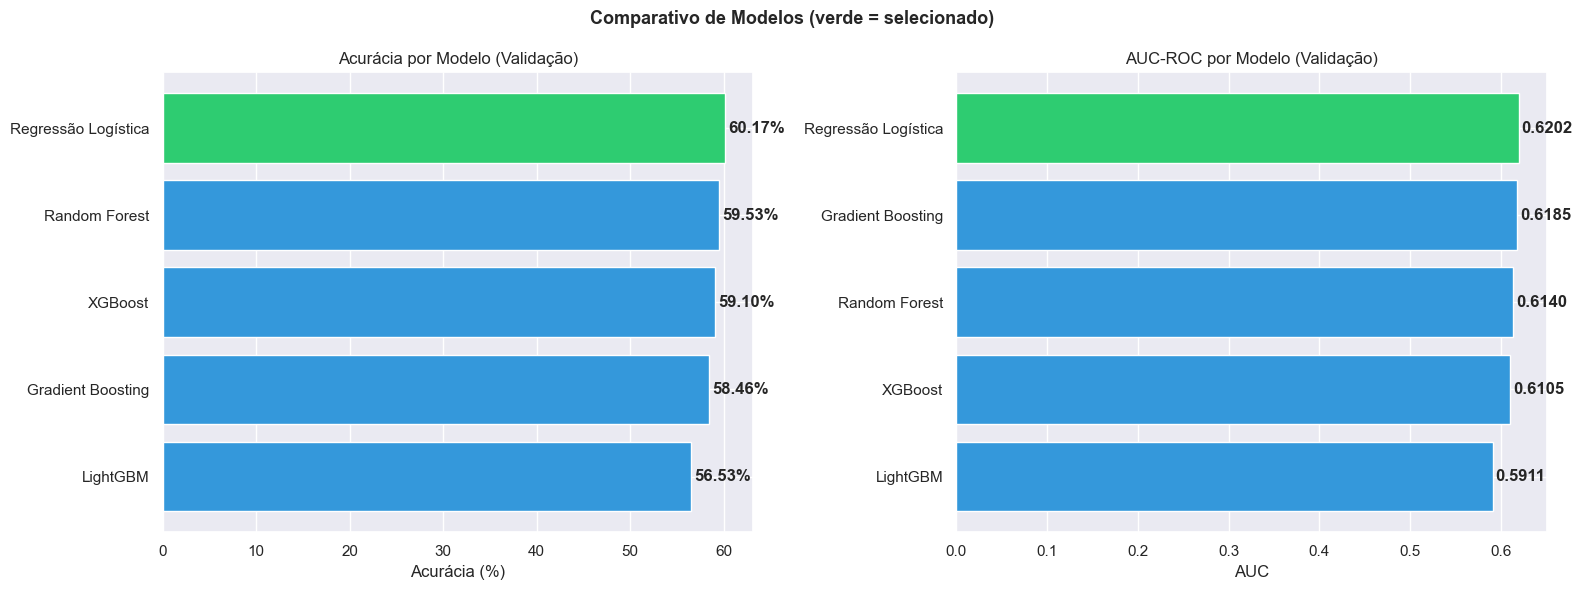

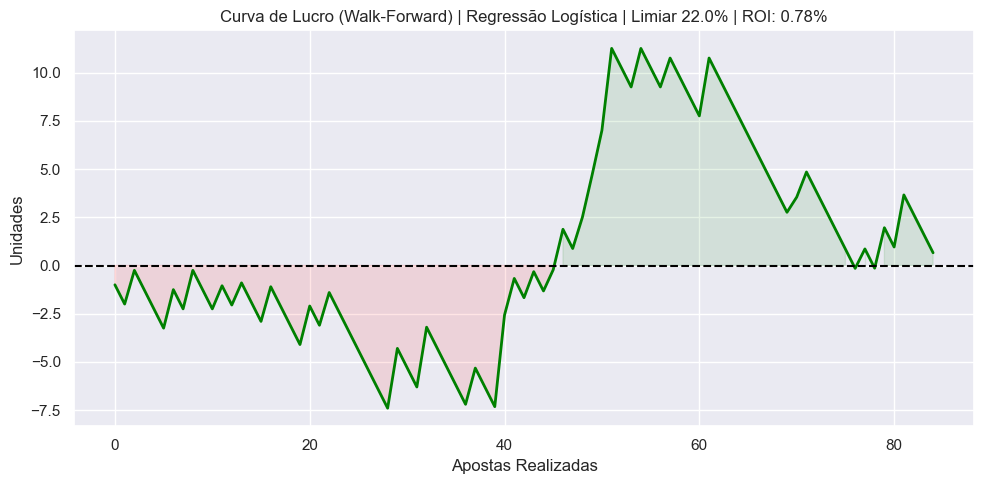

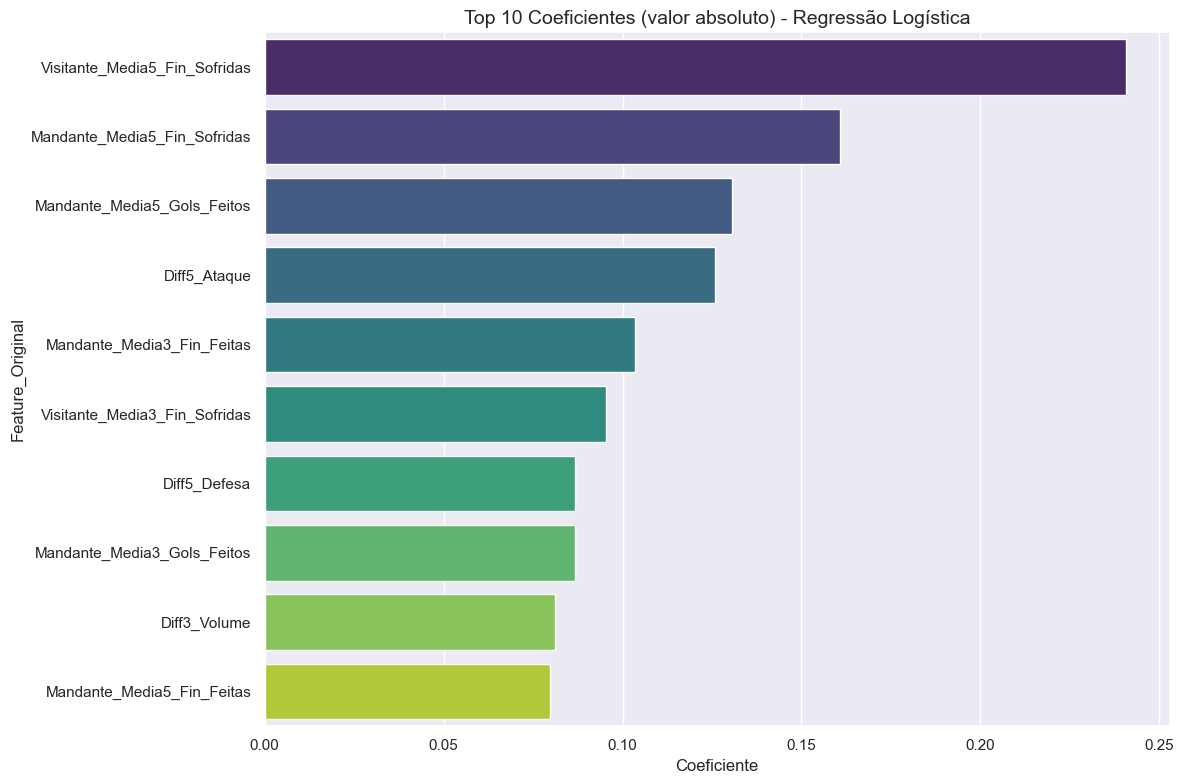

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone
from scipy.stats import uniform, randint
import warnings
import sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# --- CONFIGURAÇÕES ---
CAMINHO_ARQUIVO = 'Campeonato_Brasileiro_Com_Clima.csv'
NOME_ARQUIVO_SAIDA = 'Relatorio_Apostas_Completo_Otimizado.xlsx'
NOME_MODELO_SALVO = 'melhor_modelo_pipeline.pkl'

# --- 1. LEITURA E TRATAMENTO ---
if os.path.exists(CAMINHO_ARQUIVO):
    try:
        df = pd.read_csv(CAMINHO_ARQUIVO)
    except:
        df = pd.read_csv(CAMINHO_ARQUIVO, sep=';', encoding='latin1')
else:
    raise FileNotFoundError(f"Arquivo '{CAMINHO_ARQUIVO}' não encontrado!")

# Conversão numérica
cols_num = ['Odd_Mandante', 'Gols_Mandante', 'Gols_Visitante', 
            'Finalizacoes_Mandante', 'Finalizacoes_Visitante']

for col in cols_num:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Ajuste de Data
if 'Data_Hora' in df.columns:
    df['Data_Hora'] = pd.to_datetime(df['Data_Hora'], dayfirst=True, errors='coerce')
    df = df.sort_values(by='Data_Hora').reset_index(drop=True)
else:
    raise ValueError("Coluna 'Data_Hora' não encontrada.")

if 'Temporada' in df.columns:
    print(f"Dados carregados: Todas as temporadas mantidas. Total de jogos: {len(df)}")

# --- 2. ENGENHARIA DE FEATURES (MOMENTO GLOBAL DAS EQUIPES) ---
janelas = [3, 5]
df_features = df.copy()

# 1. EMPILHAR: Criar um DataFrame único
df_mandante = df[['Data_Hora', 'Mandante', 'Gols_Mandante', 'Gols_Visitante', 'Finalizacoes_Mandante', 'Finalizacoes_Visitante']].copy()
df_mandante.rename(columns={'Mandante': 'Equipe', 'Gols_Mandante': 'Gols_Feitos', 'Gols_Visitante': 'Gols_Sofridos', 'Finalizacoes_Mandante': 'Fin_Feitas', 'Finalizacoes_Visitante': 'Fin_Sofridas'}, inplace=True)

df_visitante = df[['Data_Hora', 'Visitante', 'Gols_Visitante', 'Gols_Mandante', 'Finalizacoes_Visitante', 'Finalizacoes_Mandante']].copy()
df_visitante.rename(columns={'Visitante': 'Equipe', 'Gols_Visitante': 'Gols_Feitos', 'Gols_Mandante': 'Gols_Sofridos', 'Finalizacoes_Visitante': 'Fin_Feitas', 'Finalizacoes_Mandante': 'Fin_Sofridas'}, inplace=True)

# Concatena e ordena cronologicamente por time
df_times = pd.concat([df_mandante, df_visitante]).sort_values(by=['Equipe', 'Data_Hora']).reset_index(drop=True)

# 2. CALCULAR: Médias móveis
cols_calc = ['Gols_Feitos', 'Gols_Sofridos', 'Fin_Feitas', 'Fin_Sofridas']

for j in janelas:
    for col in cols_calc:
        df_times[f'Media{j}_{col}'] = df_times.groupby('Equipe')[col].transform(
            lambda x: x.shift(1).rolling(window=j, min_periods=1).mean()
        )

cols_merge = ['Data_Hora', 'Equipe'] + [c for c in df_times.columns if 'Media' in c]
df_times_stats = df_times[cols_merge]

# 3. MESCLAR: Cruzar de volta para a visão de Partida
df_features = df_features.merge(df_times_stats, left_on=['Data_Hora', 'Mandante'], right_on=['Data_Hora', 'Equipe'], how='left').drop(columns=['Equipe'])
rename_m = {c: f'Mandante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_m, inplace=True)

df_features = df_features.merge(df_times_stats, left_on=['Data_Hora', 'Visitante'], right_on=['Data_Hora', 'Equipe'], how='left').drop(columns=['Equipe'])
rename_v = {c: f'Visitante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_v, inplace=True)

# 4. CRIAR DIFERENCIAIS
for j in janelas:
    df_features[f'Diff{j}_Ataque'] = df_features[f'Mandante_Media{j}_Gols_Feitos'] - df_features[f'Visitante_Media{j}_Gols_Feitos']
    df_features[f'Diff{j}_Defesa'] = df_features[f'Mandante_Media{j}_Gols_Sofridos'] - df_features[f'Visitante_Media{j}_Gols_Sofridos']
    df_features[f'Diff{j}_Volume'] = df_features[f'Mandante_Media{j}_Fin_Feitas'] - df_features[f'Visitante_Media{j}_Fin_Feitas']

# Definir o Alvo
df_features['Alvo_Vitoria'] = (df_features['Gols_Mandante'] > df_features['Gols_Visitante']).astype(int)

# Separar colunas pro modelo
colunas_treino = [c for c in df_features.columns if ('Media' in c or 'Diff' in c)]
cols_essenciais = colunas_treino + ['Odd_Mandante', 'Alvo_Vitoria', 'Mandante', 'Visitante', 'Data_Hora']

# Limpar jogos sem histórico
df_modelo = df_features.dropna(subset=cols_essenciais).copy()
df_modelo = df_modelo[df_modelo['Odd_Mandante'] > 1.01]
df_modelo = df_modelo.sort_values(by='Data_Hora').reset_index(drop=True)

# --- 3. PREPARAÇÃO (3 SPLITS TEMPORAIS: 60% TREINO, 20% VALIDAÇÃO, 20% TESTE) ---
n = len(df_modelo)
idx_treino = int(n * 0.60)
idx_val = int(n * 0.80)

X = df_modelo[colunas_treino]
y = df_modelo['Alvo_Vitoria']

X_treino, y_treino = X.iloc[:idx_treino], y.iloc[:idx_treino]
X_val, y_val = X.iloc[idx_treino:idx_val], y.iloc[idx_treino:idx_val]
X_teste, y_teste = X.iloc[idx_val:], y.iloc[idx_val:]

print("-" * 50)
print(f"Jogos para TREINO:    {len(X_treino)} (60%)")
print(f"Jogos para VALIDAÇÃO: {len(X_val)} (20%)")
print(f"Jogos para TESTE:     {len(X_teste)} (20%)")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=3)
resultados_modelos = {}

def treinar_modelo(nome, pipe, param_dist, tem_feature_importance):
    print(f"\n{'=' * 50}")
    print(f">>> Buscando Hiperparâmetros: {nome}...")
    print(f"{'=' * 50}")
    
    # ALVO DA MELHORIA: Aumentado para 100 iterações para garantir significância estatística
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=100, 
        scoring='neg_log_loss',
        cv=tscv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    rs.fit(X_treino, y_treino)
    
    melhor_pipe = rs.best_estimator_
    
    probs_val = melhor_pipe.predict_proba(X_val)[:, 1]
    preds_val = melhor_pipe.predict(X_val)
    acc_val = accuracy_score(y_val, preds_val) * 100
    auc_val = roc_auc_score(y_val, probs_val)
    
    resultados_modelos[nome] = {
        'pipeline': melhor_pipe,
        'probs_val': probs_val,
        'preds_val': preds_val,
        'acuracia_val': acc_val,
        'auc_val': auc_val,
        'best_params': rs.best_params_,
        'best_score': rs.best_score_, 
        'tem_feature_importance': tem_feature_importance,
    }
    
    print(f"  Melhores params: {rs.best_params_}")
    print(f"  CV Score (treino): {rs.best_score_:.4f}")
    print(f"  Acurácia (validação): {acc_val:.2f}% | AUC (validação): {auc_val:.4f}")

# ---- DEFINIÇÃO DOS PIPELINES E ESPAÇOS DE BUSCA (Formatados PEP 8) ----

treinar_modelo(
    'Regressão Logística', 
    Pipeline([('scaler', RobustScaler()), ('model', LogisticRegression(random_state=42, n_jobs=-1))]),
    {
        'model__C': uniform(0.001, 100), 
        'model__penalty': ['l1', 'l2'], 
        'model__solver': ['saga'], 
        'model__max_iter': [5000]
    }, 
    False
)

treinar_modelo(
    'Random Forest', 
    Pipeline([('scaler', RobustScaler()), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    {
        'model__n_estimators': randint(1000, 3000), 
        'model__max_depth': randint(3, 15), 
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 15), 
        'model__max_features': ['sqrt', 'log2', None], 
        'model__bootstrap': [True]
    }, 
    True
)

treinar_modelo(
    'XGBoost', 
    Pipeline([('scaler', RobustScaler()), ('model', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_jobs=-1, random_state=42))]),
    {
        'model__n_estimators': randint(1500, 4000), 
        'model__learning_rate': uniform(0.001, 0.05),
        'model__max_depth': randint(3, 10), 
        'model__subsample': uniform(0.6, 0.4), 
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_weight': randint(1, 10), 
        'model__gamma': uniform(0, 0.5)
    }, 
    True
)

treinar_modelo(
    'LightGBM', 
    Pipeline([('scaler', RobustScaler()), ('model', lgb.LGBMClassifier(objective='binary', metric='binary_logloss', n_jobs=-1, random_state=42, verbose=-1))]),
    {
        'model__n_estimators': randint(1500, 4000), 
        'model__learning_rate': uniform(0.001, 0.05),
        'model__max_depth': randint(3, 12), 
        'model__num_leaves': randint(15, 127), 
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4), 
        'model__min_child_samples': randint(5, 50),
        'model__reg_alpha': uniform(0, 1), 
        'model__reg_lambda': uniform(0, 1)
    }, 
    True
)

treinar_modelo(
    'Gradient Boosting', 
    Pipeline([('scaler', RobustScaler()), ('model', GradientBoostingClassifier(random_state=42))]),
    {
        'model__n_estimators': randint(1000, 3000), 
        'model__learning_rate': uniform(0.005, 0.05), 
        'model__max_depth': randint(3, 10),
        'model__min_samples_split': randint(2, 20), 
        'model__min_samples_leaf': randint(1, 15), 
        'model__subsample': uniform(0.6, 0.4),
        'model__max_features': ['sqrt', 'log2', None]
    }, 
    True
)

# ==========================================================
# --- COMPARATIVO E SELEÇÃO DO MELHOR MODELO
# ==========================================================
print("\n" + "=" * 75)
print("        COMPARATIVO FINAL DOS MODELOS")
print("=" * 75)
print(f"{'Modelo':<25} {'CV Score (Treino)':>18} {'AUC (Validação)':>16} {'Acur. (Valid.)':>15}")
print("-" * 75)

for nome, info in resultados_modelos.items():
    print(f"{nome:<25} {info['best_score']:>17.4f} {info['auc_val']:>15.4f} {info['acuracia_val']:>13.2f}%")

nome_melhor = max(resultados_modelos, key=lambda k: resultados_modelos[k]['auc_val'])
info_melhor = resultados_modelos[nome_melhor]
pipeline_melhor = info_melhor['pipeline']

print(f"\n>>> MELHOR MODELO SELECIONADO: {nome_melhor} (CV Score = {info_melhor['best_score']:.4f})")

# --- 4. OTIMIZAÇÃO DO LIMIAR DE EV NA VALIDAÇÃO ---
print("\n>>> Otimizando Limiar de Valor na VALIDAÇÃO...")

df_val_sim = df_modelo.iloc[idx_treino:idx_val].copy()
df_val_sim['Prob_Modelo'] = info_melhor['probs_val']
df_val_sim['Odd_Justa_Modelo'] = 1 / df_val_sim['Prob_Modelo']
df_val_sim['EV_Porcentagem'] = (df_val_sim['Odd_Mandante'] / df_val_sim['Odd_Justa_Modelo']) - 1

lista_limiares_fina = np.arange(0.0, 0.31, 0.01)
melhor_limiar = 0.0
melhor_lucro_loop = -999999

for val_limiar in lista_limiares_fina:
    mask = df_val_sim['EV_Porcentagem'] > val_limiar
    sub_df = df_val_sim[mask]
    if len(sub_df) >= 10:
        lucro_temp = np.where(sub_df['Alvo_Vitoria'] == 1, sub_df['Odd_Mandante'] - 1, -1).sum()
        if lucro_temp > melhor_lucro_loop:
            melhor_lucro_loop = lucro_temp
            melhor_limiar = val_limiar

print(f"Limiar Vencedor (validação): {melhor_limiar*100:.1f}% com Lucro: {melhor_lucro_loop:.2f}u")
LIMIAR_VALOR = melhor_limiar

# ==========================================================
# --- 5. AVALIAÇÃO FINAL NO TESTE (WALK-FORWARD) ---
# ==========================================================
print("\n>>> Aplicando modelo no TESTE com Walk-Forward Validation (Re-treino diário)...")

# Histórico base engloba Treino + Validação
X_hist_atual = pd.concat([X_treino, X_val]).copy()
y_hist_atual = pd.concat([y_treino, y_val]).copy()

df_teste_wf = df_modelo.iloc[idx_val:].copy()
df_teste_wf['Data_Apenas'] = df_teste_wf['Data_Hora'].dt.date
datas_teste = df_teste_wf['Data_Apenas'].unique()

# Clona a estrutura do pipeline com os hiperparâmetros campeões
modelo_producao = clone(pipeline_melhor)

probs_teste_wf = []
preds_teste_wf = []

for i, data_atual in enumerate(datas_teste):
    sys.stdout.write(f"\rProgresso Walk-Forward: Processando dia {i+1}/{len(datas_teste)} ({data_atual})")
    sys.stdout.flush()
    
    # Isola os jogos do dia específico no Teste
    jogos_dia_idx = df_teste_wf[df_teste_wf['Data_Apenas'] == data_atual].index
    X_dia = X_teste.loc[jogos_dia_idx]
    
    # Treina o modelo com todo o histórico acumulado até aquele dia
    modelo_producao.fit(X_hist_atual, y_hist_atual)
    
    # Faz as predições para os jogos do dia
    probs_dia = modelo_producao.predict_proba(X_dia)[:, 1]
    preds_dia = modelo_producao.predict(X_dia)
    
    probs_teste_wf.extend(probs_dia)
    preds_teste_wf.extend(preds_dia)
    
    # Adiciona os jogos deste dia ao histórico para treinar o modelo pro dia seguinte
    X_hist_atual = pd.concat([X_hist_atual, X_dia], ignore_index=True)
    y_hist_atual = pd.concat([y_hist_atual, y_teste.loc[jogos_dia_idx]], ignore_index=True)

print("\nConcluído!")

# Converte os resultados do Walk-Forward de volta para arrays
probs_teste = np.array(probs_teste_wf)
preds_teste = np.array(preds_teste_wf)

acc_teste = accuracy_score(y_teste, preds_teste) * 100
auc_teste = roc_auc_score(y_teste, probs_teste)

print(f"\nClassification Report no TESTE (Walk-Forward | {nome_melhor}):")
print(classification_report(y_teste, preds_teste, target_names=['Derrota/Empate', 'Vitória Mandante']))

df_base_teste = df_modelo.iloc[idx_val:].copy()
df_base_teste['Prob_Modelo'] = probs_teste
df_base_teste['Odd_Justa_Modelo'] = 1 / df_base_teste['Prob_Modelo']
df_base_teste['Prob_Bookie'] = 1 / df_base_teste['Odd_Mandante']
df_base_teste['EV_Porcentagem'] = (df_base_teste['Odd_Mandante'] / df_base_teste['Odd_Justa_Modelo']) - 1

# --- 6. SALVAR PIPELINE ---
pipeline_salvo = {
    'pipeline': pipeline_melhor, 
    'LIMIAR_VALOR': LIMIAR_VALOR,
    'colunas_treino': colunas_treino,
    'nome_modelo': nome_melhor,
    'best_params': info_melhor['best_params'],
    'acuracia_teste': acc_teste,
    'auc_teste': auc_teste,
}

joblib.dump(pipeline_salvo, NOME_MODELO_SALVO)
print(f"\n>>> Pipeline salvo em: {NOME_MODELO_SALVO}")

# --- 7. APLICAÇÃO DO LIMIAR NO TESTE E CÁLCULOS ---
df_apostas = df_base_teste[df_base_teste['EV_Porcentagem'] > LIMIAR_VALOR].copy()

df_apostas['Resultado_Aposta'] = np.where(df_apostas['Alvo_Vitoria'] == 1, 
                                          df_apostas['Odd_Mandante'] - 1, -1)
df_apostas['Lucro_Acumulado'] = df_apostas['Resultado_Aposta'].cumsum()

# --- EXPORTAÇÃO EXCEL ---
colunas_finais = [
    'Data_Hora', 'Mandante', 'Visitante', 'Gols_Mandante', 'Gols_Visitante', 
    'Odd_Mandante', 'Odd_Justa_Modelo',
    'Prob_Bookie', 'Prob_Modelo', 'EV_Porcentagem', 'Resultado_Aposta'
]
df_export = df_apostas[colunas_finais].copy()

df_export['Prob_Bookie'] = (df_export['Prob_Bookie'] * 100).round(2)
df_export['Prob_Modelo'] = (df_export['Prob_Modelo'] * 100).round(2)
df_export['EV_Porcentagem'] = (df_export['EV_Porcentagem'] * 100).round(2)
df_export = df_export.round(2)

df_export.rename(columns={
    'Odd_Mandante': 'Odd Mandante',
    'Odd_Justa_Modelo': 'Odd Modelo',
    'Prob_Bookie': 'Probabilidade Odd Mandante em %',
    'Prob_Modelo': 'Probabilidade Modelo em %',
    'EV_Porcentagem': 'Valor Esperado em %',
    'Resultado_Aposta': 'Lucro/Prejuízo'
}, inplace=True)

df_export.to_excel(NOME_ARQUIVO_SAIDA, index=False)

# --- ANÁLISE E INTERVALO DE CONFIANÇA ---
total_apostas = len(df_export)
lucro_final = df_export['Lucro/Prejuízo'].sum()
roi = (lucro_final / total_apostas * 100) if total_apostas > 0 else 0

odd_media_geral = df_modelo['Odd_Mandante'].mean()
prob_media_geral = (1 / odd_media_geral * 100) if odd_media_geral > 0 else 0

max_green_run = 0
max_bad_run = 0

if total_apostas > 0:
    winrate_metodo = (df_apostas['Alvo_Vitoria'].sum() / total_apostas) * 100
    odd_media_apostas = df_apostas['Odd_Mandante'].mean()
    prob_impl_media_apostas = (1 / odd_media_apostas * 100)
    prob_modelo_media_apostas = df_apostas['Prob_Modelo'].mean() * 100
    
    apostas_seq = df_apostas.sort_values(by='Data_Hora')['Resultado_Aposta'].values
    current_green = 0
    current_bad = 0
    for resultado in apostas_seq:
        if resultado > 0:
            current_green += 1
            current_bad = 0
            if current_green > max_green_run:
                max_green_run = current_green
        else:
            current_bad += 1
            current_green = 0
            if current_bad > max_bad_run:
                max_bad_run = current_bad
else:
    winrate_metodo = 0.0
    odd_media_apostas = 0.0
    prob_impl_media_apostas = 0.0
    prob_modelo_media_apostas = 0.0

if total_apostas > 10:
    resultados_bootstrap = []
    resultados_reais = df_apostas['Resultado_Aposta'].values
    for _ in range(100):
        amostra = np.random.choice(resultados_reais, size=len(resultados_reais), replace=True)
        roi_simulado = (amostra.sum() / len(amostra)) * 100
        resultados_bootstrap.append(roi_simulado)
    ic_inf = np.percentile(resultados_bootstrap, 2.5)
    ic_sup = np.percentile(resultados_bootstrap, 97.5)
    texto_ic = f"Intervalo Confiança (95%): {ic_inf:.2f}% a {ic_sup:.2f}%"
else:
    texto_ic = "Poucas apostas para calcular IC."


# --- PRINTS DETALHADOS ---
print("Versão do sklearn rodando AGORA no código:", sklearn.__version__)
print(f"\nANÁLISE DETALHADA DO MODELO (Walk-Forward Validation)")
print(f"==================================================")
print(f"MODELO SELECIONADO: {nome_melhor}")
print(f"==================================================")
print(f"DADOS GERAIS:")
print(f"  - Odd Média Geral:       {odd_media_geral:.2f}")
print(f"  - Prob. Implícita Geral: {prob_media_geral:.2f}%")
print(f"  - Acurácia no TESTE:     {acc_teste:.2f}%")
print(f"  - AUC no TESTE:          {auc_teste:.4f}")
print(f"==================================================")
print(f"DADOS DO MÉTODO (Limiar > {LIMIAR_VALOR*100:.1f}% EV):")
print(f"  - Quantidade de Apostas: {total_apostas}")
print(f"  - Winrate Real:          {winrate_metodo:.2f}%")
print(f"--------------------------------------------------")
print(f"  SEQUÊNCIAS (Stress Test):")
print(f"  - Maior Green Run:       {max_green_run} jogos seguidos")
print(f"  - Maior Bad Run:         {max_bad_run} jogos seguidos")
print(f"--------------------------------------------------")
print(f"  COMPARATIVO DE PROBABILIDADES:")
print(f"  - Odd Média das Apostas: {odd_media_apostas:.2f}")
print(f"  - Prob. da casa:         {prob_impl_media_apostas:.2f}%")
print(f"  - Prob. do Modelo:       {prob_modelo_media_apostas:.2f}%")
print(f"--------------------------------------------------")
print(f"RESULTADO FINANCEIRO (TESTE - Walk-Forward):")
print(f"  - ROI Final:             {roi:.2f}%")
print(f"  - Lucro Líquido:         {lucro_final:.2f} unidades")
print(f"  - {texto_ic}")
print(f"==================================================")
print(f"Excel salvo em: {NOME_ARQUIVO_SAIDA}")

# --- 8. GRÁFICOS ---
if total_apostas > 0:
    # --- Gráfico Comparativo dos Modelos (ordenado) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    nomes_ord_acc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['acuracia_val'])
    acc_ord = [resultados_modelos[n]['acuracia_val'] for n in nomes_ord_acc]
    cores_acc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_acc]
    
    axes[0].barh(nomes_ord_acc, acc_ord, color=cores_acc)
    axes[0].set_xlabel('Acurácia (%)')
    axes[0].set_title('Acurácia por Modelo (Validação)')
    for i, v in enumerate(acc_ord):
        axes[0].text(v + 0.3, i, f'{v:.2f}%', va='center', fontweight='bold')
    
    nomes_ord_auc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['auc_val'])
    auc_ord = [resultados_modelos[n]['auc_val'] for n in nomes_ord_auc]
    cores_auc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_auc]
    
    axes[1].barh(nomes_ord_auc, auc_ord, color=cores_auc)
    axes[1].set_xlabel('AUC')
    axes[1].set_title('AUC-ROC por Modelo (Validação)')
    for i, v in enumerate(auc_ord):
        axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold')
    
    fig.suptitle('Comparativo de Modelos (verde = selecionado)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Curva de Lucro no TESTE ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(df_apostas)), y=df_apostas['Lucro_Acumulado'], 
                 linewidth=2, color='green' if lucro_final > 0 else 'red')
    plt.axhline(0, color='black', linestyle='--')
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] >= 0), color='green', alpha=0.1)
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] < 0), color='red', alpha=0.1)
    plt.title(f"Curva de Lucro (Walk-Forward) | {nome_melhor} | Limiar {LIMIAR_VALOR*100:.1f}% | ROI: {roi:.2f}%", fontsize=12)
    plt.xlabel("Apostas Realizadas")
    plt.ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # --- Feature Importance (Usando o pipeline treinado na validação base) ---
    modelo_interno = pipeline_melhor.named_steps['model']
    if info_melhor['tem_feature_importance']:
        mapa_nomes = {
            'Diff3_Ataque': 'Saldo Ataque (3 jogos)',
            'Diff5_Ataque': 'Saldo Ataque (5 jogos)',
            'Diff3_Defesa': 'Saldo Defesa (3 jogos)',
            'Diff5_Defesa': 'Saldo Defesa (5 jogos)',
            'Diff3_Volume': 'Saldo Volume/Fin. (3 jogos)'
        }
        
        # Correção extra para garantir que o número de features bate com a importância
        try:
            importancia = pd.DataFrame({
                'Feature_Original': colunas_treino,
                'Importancia': modelo_interno.feature_importances_
            })
            importancia['Nome_Explicito'] = importancia['Feature_Original'].map(mapa_nomes).fillna(importancia['Feature_Original'])
            importancia = importancia.sort_values(by='Importancia', ascending=False).head(10)

            plt.figure(figsize=(12, 8))
            sns.barplot(data=importancia, x='Importancia', y='Nome_Explicito', palette='viridis')
            plt.title(f"Top 10 Fatores Decisivos Base ({nome_melhor})", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"\nNão foi possível plotar a importância de features: {e}")
            
    else:
        if hasattr(modelo_interno, 'coef_'):
            try:
                coefs = pd.DataFrame({
                    'Feature_Original': colunas_treino,
                    'Coeficiente': np.abs(modelo_interno.coef_[0])
                }).sort_values(by='Coeficiente', ascending=False).head(10)
                
                plt.figure(figsize=(12, 8))
                sns.barplot(data=coefs, x='Coeficiente', y='Feature_Original', palette='viridis')
                plt.title(f"Top 10 Coeficientes (valor absoluto) - {nome_melhor}", fontsize=14)
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"\nNão foi possível plotar os coeficientes: {e}")
        else:
            print(f"\nO modelo {nome_melhor} não possui atributo de importância de features nativo.")

else:
    print("\nNenhuma aposta encontrada com os critérios definidos.")

Premier League

Dados carregados: Todas as temporadas mantidas. Total de jogos: 2596
--------------------------------------------------
Jogos para TREINO:    1546 (60%)
Jogos para VALIDAÇÃO: 515 (20%)
Jogos para TESTE:     516 (20%)
--------------------------------------------------

>>> Buscando Hiperparâmetros: Regressão Logística...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
  Melhores params: {'model__C': 0.07887658410143283, 'model__max_iter': 5000, 'model__penalty': 'l2', 'model__solver': 'saga'}
  CV Score (treino): -0.6280
  Acurácia (validação): 65.05% | AUC (validação): 0.7020

>>> Buscando Hiperparâmetros: Random Forest...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
  Melhores params: {'model__bootstrap': True, 'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 12, 'model__min_samples_split': 17, 'model__n_estimators': 1217}
  CV Score (treino): -0.6346
  Acurácia (validação): 65.44% | AUC (validação): 0.7004

>>> Buscando

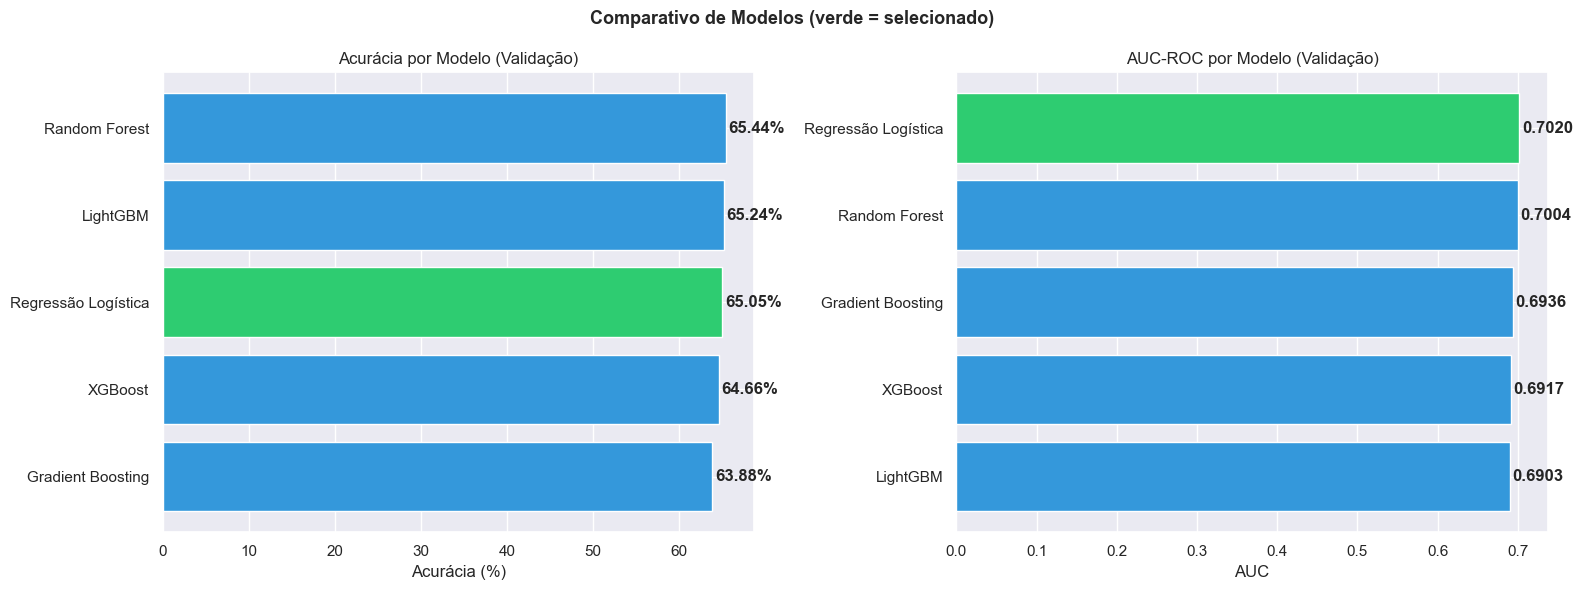

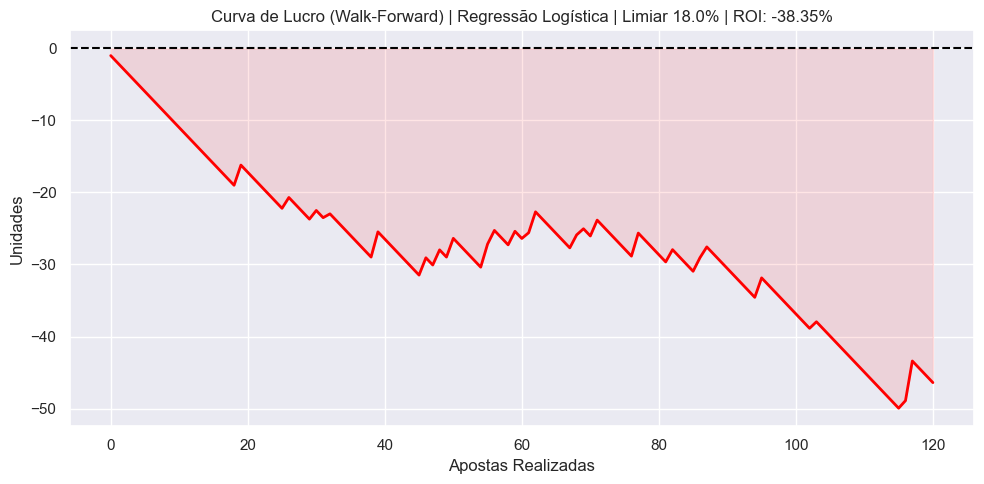

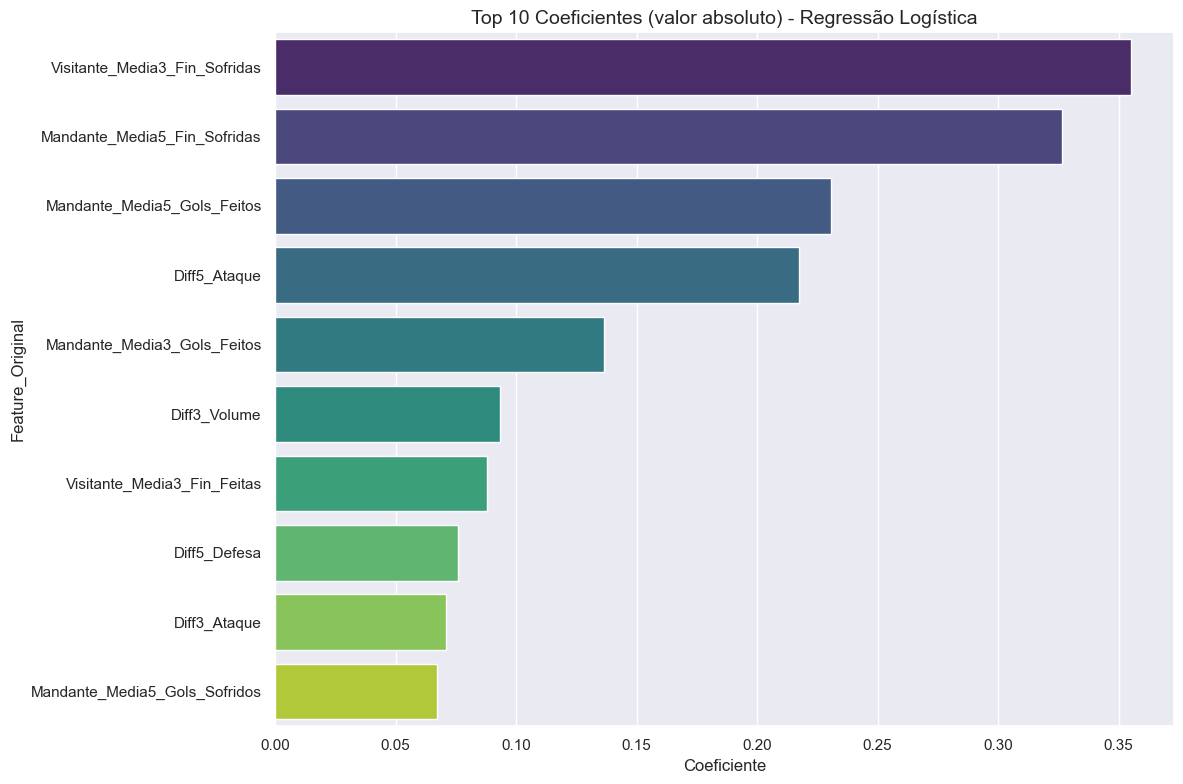

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone
from scipy.stats import uniform, randint
import warnings
import sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# --- CONFIGURAÇÕES ---
CAMINHO_ARQUIVO = 'Campeonato_Premier_League_Com_Clima.csv'
NOME_ARQUIVO_SAIDA = 'Relatorio_Apostas_Completo_premier.xlsx'
NOME_MODELO_SALVO = 'melhor_modelo_pipeline_premier.pkl'

# --- 1. LEITURA E TRATAMENTO ---
if os.path.exists(CAMINHO_ARQUIVO):
    try:
        df = pd.read_csv(CAMINHO_ARQUIVO)
    except:
        df = pd.read_csv(CAMINHO_ARQUIVO, sep=';', encoding='latin1')
else:
    raise FileNotFoundError(f"Arquivo '{CAMINHO_ARQUIVO}' não encontrado!")

# Conversão numérica
cols_num = ['Odd_Mandante', 'Gols_Mandante', 'Gols_Visitante', 
            'Finalizacoes_Mandante', 'Finalizacoes_Visitante']

for col in cols_num:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Ajuste de Data
if 'Data_Hora' in df.columns:
    df['Data_Hora'] = pd.to_datetime(df['Data_Hora'], dayfirst=True, errors='coerce')
    df = df.sort_values(by='Data_Hora').reset_index(drop=True)
else:
    raise ValueError("Coluna 'Data_Hora' não encontrada.")

if 'Temporada' in df.columns:
    print(f"Dados carregados: Todas as temporadas mantidas. Total de jogos: {len(df)}")

# --- 2. ENGENHARIA DE FEATURES (MOMENTO GLOBAL DAS EQUIPES) ---
janelas = [3, 5]
df_features = df.copy()

# 1. EMPILHAR: Criar um DataFrame único
df_mandante = df[['Data_Hora', 'Mandante', 'Gols_Mandante', 'Gols_Visitante', 'Finalizacoes_Mandante', 'Finalizacoes_Visitante']].copy()
df_mandante.rename(columns={'Mandante': 'Equipe', 'Gols_Mandante': 'Gols_Feitos', 'Gols_Visitante': 'Gols_Sofridos', 'Finalizacoes_Mandante': 'Fin_Feitas', 'Finalizacoes_Visitante': 'Fin_Sofridas'}, inplace=True)

df_visitante = df[['Data_Hora', 'Visitante', 'Gols_Visitante', 'Gols_Mandante', 'Finalizacoes_Visitante', 'Finalizacoes_Mandante']].copy()
df_visitante.rename(columns={'Visitante': 'Equipe', 'Gols_Visitante': 'Gols_Feitos', 'Gols_Mandante': 'Gols_Sofridos', 'Finalizacoes_Visitante': 'Fin_Feitas', 'Finalizacoes_Mandante': 'Fin_Sofridas'}, inplace=True)

# Concatena e ordena cronologicamente por time
df_times = pd.concat([df_mandante, df_visitante]).sort_values(by=['Equipe', 'Data_Hora']).reset_index(drop=True)

# 2. CALCULAR: Médias móveis
cols_calc = ['Gols_Feitos', 'Gols_Sofridos', 'Fin_Feitas', 'Fin_Sofridas']

for j in janelas:
    for col in cols_calc:
        df_times[f'Media{j}_{col}'] = df_times.groupby('Equipe')[col].transform(
            lambda x: x.shift(1).rolling(window=j, min_periods=1).mean()
        )

cols_merge = ['Data_Hora', 'Equipe'] + [c for c in df_times.columns if 'Media' in c]
df_times_stats = df_times[cols_merge]

# 3. MESCLAR: Cruzar de volta para a visão de Partida
df_features = df_features.merge(df_times_stats, left_on=['Data_Hora', 'Mandante'], right_on=['Data_Hora', 'Equipe'], how='left').drop(columns=['Equipe'])
rename_m = {c: f'Mandante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_m, inplace=True)

df_features = df_features.merge(df_times_stats, left_on=['Data_Hora', 'Visitante'], right_on=['Data_Hora', 'Equipe'], how='left').drop(columns=['Equipe'])
rename_v = {c: f'Visitante_{c}' for c in df_times_stats.columns if 'Media' in c}
df_features.rename(columns=rename_v, inplace=True)

# 4. CRIAR DIFERENCIAIS
for j in janelas:
    df_features[f'Diff{j}_Ataque'] = df_features[f'Mandante_Media{j}_Gols_Feitos'] - df_features[f'Visitante_Media{j}_Gols_Feitos']
    df_features[f'Diff{j}_Defesa'] = df_features[f'Mandante_Media{j}_Gols_Sofridos'] - df_features[f'Visitante_Media{j}_Gols_Sofridos']
    df_features[f'Diff{j}_Volume'] = df_features[f'Mandante_Media{j}_Fin_Feitas'] - df_features[f'Visitante_Media{j}_Fin_Feitas']

# Definir o Alvo
df_features['Alvo_Vitoria'] = (df_features['Gols_Mandante'] > df_features['Gols_Visitante']).astype(int)

# Separar colunas pro modelo
colunas_treino = [c for c in df_features.columns if ('Media' in c or 'Diff' in c)]
cols_essenciais = colunas_treino + ['Odd_Mandante', 'Alvo_Vitoria', 'Mandante', 'Visitante', 'Data_Hora']

# Limpar jogos sem histórico
df_modelo = df_features.dropna(subset=cols_essenciais).copy()
df_modelo = df_modelo[df_modelo['Odd_Mandante'] > 1.01]
df_modelo = df_modelo.sort_values(by='Data_Hora').reset_index(drop=True)

# --- 3. PREPARAÇÃO (3 SPLITS TEMPORAIS: 60% TREINO, 20% VALIDAÇÃO, 20% TESTE) ---
n = len(df_modelo)
idx_treino = int(n * 0.60)
idx_val = int(n * 0.80)

X = df_modelo[colunas_treino]
y = df_modelo['Alvo_Vitoria']

X_treino, y_treino = X.iloc[:idx_treino], y.iloc[:idx_treino]
X_val, y_val = X.iloc[idx_treino:idx_val], y.iloc[idx_treino:idx_val]
X_teste, y_teste = X.iloc[idx_val:], y.iloc[idx_val:]

print("-" * 50)
print(f"Jogos para TREINO:    {len(X_treino)} (60%)")
print(f"Jogos para VALIDAÇÃO: {len(X_val)} (20%)")
print(f"Jogos para TESTE:     {len(X_teste)} (20%)")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=3)
resultados_modelos = {}

def treinar_modelo(nome, pipe, param_dist, tem_feature_importance):
    print(f"\n{'=' * 50}")
    print(f">>> Buscando Hiperparâmetros: {nome}...")
    print(f"{'=' * 50}")
    
    # ALVO DA MELHORIA: Aumentado para 100 iterações para garantir significância estatística
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=100, 
        scoring='neg_log_loss',
        cv=tscv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    rs.fit(X_treino, y_treino)
    
    melhor_pipe = rs.best_estimator_
    
    probs_val = melhor_pipe.predict_proba(X_val)[:, 1]
    preds_val = melhor_pipe.predict(X_val)
    acc_val = accuracy_score(y_val, preds_val) * 100
    auc_val = roc_auc_score(y_val, probs_val)
    
    resultados_modelos[nome] = {
        'pipeline': melhor_pipe,
        'probs_val': probs_val,
        'preds_val': preds_val,
        'acuracia_val': acc_val,
        'auc_val': auc_val,
        'best_params': rs.best_params_,
        'best_score': rs.best_score_, 
        'tem_feature_importance': tem_feature_importance,
    }
    
    print(f"  Melhores params: {rs.best_params_}")
    print(f"  CV Score (treino): {rs.best_score_:.4f}")
    print(f"  Acurácia (validação): {acc_val:.2f}% | AUC (validação): {auc_val:.4f}")

# ---- DEFINIÇÃO DOS PIPELINES E ESPAÇOS DE BUSCA (Formatados PEP 8) ----

treinar_modelo(
    'Regressão Logística', 
    Pipeline([('scaler', RobustScaler()), ('model', LogisticRegression(random_state=42, n_jobs=-1))]),
    {
        'model__C': uniform(0.001, 100), 
        'model__penalty': ['l1', 'l2'], 
        'model__solver': ['saga'], 
        'model__max_iter': [5000]
    }, 
    False
)

treinar_modelo(
    'Random Forest', 
    Pipeline([('scaler', RobustScaler()), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    {
        'model__n_estimators': randint(1000, 3000), 
        'model__max_depth': randint(3, 15), 
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 15), 
        'model__max_features': ['sqrt', 'log2', None], 
        'model__bootstrap': [True]
    }, 
    True
)

treinar_modelo(
    'XGBoost', 
    Pipeline([('scaler', RobustScaler()), ('model', xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_jobs=-1, random_state=42))]),
    {
        'model__n_estimators': randint(1500, 4000), 
        'model__learning_rate': uniform(0.001, 0.05),
        'model__max_depth': randint(3, 10), 
        'model__subsample': uniform(0.6, 0.4), 
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_weight': randint(1, 10), 
        'model__gamma': uniform(0, 0.5)
    }, 
    True
)

treinar_modelo(
    'LightGBM', 
    Pipeline([('scaler', RobustScaler()), ('model', lgb.LGBMClassifier(objective='binary', metric='binary_logloss', n_jobs=-1, random_state=42, verbose=-1))]),
    {
        'model__n_estimators': randint(1500, 4000), 
        'model__learning_rate': uniform(0.001, 0.05),
        'model__max_depth': randint(3, 12), 
        'model__num_leaves': randint(15, 127), 
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4), 
        'model__min_child_samples': randint(5, 50),
        'model__reg_alpha': uniform(0, 1), 
        'model__reg_lambda': uniform(0, 1)
    }, 
    True
)

treinar_modelo(
    'Gradient Boosting', 
    Pipeline([('scaler', RobustScaler()), ('model', GradientBoostingClassifier(random_state=42))]),
    {
        'model__n_estimators': randint(1000, 3000), 
        'model__learning_rate': uniform(0.005, 0.05), 
        'model__max_depth': randint(3, 10),
        'model__min_samples_split': randint(2, 20), 
        'model__min_samples_leaf': randint(1, 15), 
        'model__subsample': uniform(0.6, 0.4),
        'model__max_features': ['sqrt', 'log2', None]
    }, 
    True
)

# ==========================================================
# --- COMPARATIVO E SELEÇÃO DO MELHOR MODELO
# ==========================================================
print("\n" + "=" * 75)
print("        COMPARATIVO FINAL DOS MODELOS")
print("=" * 75)
print(f"{'Modelo':<25} {'CV Score (Treino)':>18} {'AUC (Validação)':>16} {'Acur. (Valid.)':>15}")
print("-" * 75)

for nome, info in resultados_modelos.items():
    print(f"{nome:<25} {info['best_score']:>17.4f} {info['auc_val']:>15.4f} {info['acuracia_val']:>13.2f}%")

nome_melhor = max(resultados_modelos, key=lambda k: resultados_modelos[k]['auc_val'])
info_melhor = resultados_modelos[nome_melhor]
pipeline_melhor = info_melhor['pipeline']

print(f"\n>>> MELHOR MODELO SELECIONADO: {nome_melhor} (CV Score = {info_melhor['best_score']:.4f})")

# --- 4. OTIMIZAÇÃO DO LIMIAR DE EV NA VALIDAÇÃO ---
print("\n>>> Otimizando Limiar de Valor na VALIDAÇÃO...")

df_val_sim = df_modelo.iloc[idx_treino:idx_val].copy()
df_val_sim['Prob_Modelo'] = info_melhor['probs_val']
df_val_sim['Odd_Justa_Modelo'] = 1 / df_val_sim['Prob_Modelo']
df_val_sim['EV_Porcentagem'] = (df_val_sim['Odd_Mandante'] / df_val_sim['Odd_Justa_Modelo']) - 1

lista_limiares_fina = np.arange(0.0, 0.31, 0.01)
melhor_limiar = 0.0
melhor_lucro_loop = -999999

for val_limiar in lista_limiares_fina:
    mask = df_val_sim['EV_Porcentagem'] > val_limiar
    sub_df = df_val_sim[mask]
    if len(sub_df) >= 10:
        lucro_temp = np.where(sub_df['Alvo_Vitoria'] == 1, sub_df['Odd_Mandante'] - 1, -1).sum()
        if lucro_temp > melhor_lucro_loop:
            melhor_lucro_loop = lucro_temp
            melhor_limiar = val_limiar

print(f"Limiar Vencedor (validação): {melhor_limiar*100:.1f}% com Lucro: {melhor_lucro_loop:.2f}u")
LIMIAR_VALOR = melhor_limiar

# ==========================================================
# --- 5. AVALIAÇÃO FINAL NO TESTE (WALK-FORWARD) ---
# ==========================================================
print("\n>>> Aplicando modelo no TESTE com Walk-Forward Validation (Re-treino diário)...")

# Histórico base engloba Treino + Validação
X_hist_atual = pd.concat([X_treino, X_val]).copy()
y_hist_atual = pd.concat([y_treino, y_val]).copy()

df_teste_wf = df_modelo.iloc[idx_val:].copy()
df_teste_wf['Data_Apenas'] = df_teste_wf['Data_Hora'].dt.date
datas_teste = df_teste_wf['Data_Apenas'].unique()

# Clona a estrutura do pipeline com os hiperparâmetros campeões
modelo_producao = clone(pipeline_melhor)

probs_teste_wf = []
preds_teste_wf = []

for i, data_atual in enumerate(datas_teste):
    sys.stdout.write(f"\rProgresso Walk-Forward: Processando dia {i+1}/{len(datas_teste)} ({data_atual})")
    sys.stdout.flush()
    
    # Isola os jogos do dia específico no Teste
    jogos_dia_idx = df_teste_wf[df_teste_wf['Data_Apenas'] == data_atual].index
    X_dia = X_teste.loc[jogos_dia_idx]
    
    # Treina o modelo com todo o histórico acumulado até aquele dia
    modelo_producao.fit(X_hist_atual, y_hist_atual)
    
    # Faz as predições para os jogos do dia
    probs_dia = modelo_producao.predict_proba(X_dia)[:, 1]
    preds_dia = modelo_producao.predict(X_dia)
    
    probs_teste_wf.extend(probs_dia)
    preds_teste_wf.extend(preds_dia)
    
    # Adiciona os jogos deste dia ao histórico para treinar o modelo pro dia seguinte
    X_hist_atual = pd.concat([X_hist_atual, X_dia], ignore_index=True)
    y_hist_atual = pd.concat([y_hist_atual, y_teste.loc[jogos_dia_idx]], ignore_index=True)

print("\nConcluído!")

# Converte os resultados do Walk-Forward de volta para arrays
probs_teste = np.array(probs_teste_wf)
preds_teste = np.array(preds_teste_wf)

acc_teste = accuracy_score(y_teste, preds_teste) * 100
auc_teste = roc_auc_score(y_teste, probs_teste)

print(f"\nClassification Report no TESTE (Walk-Forward | {nome_melhor}):")
print(classification_report(y_teste, preds_teste, target_names=['Derrota/Empate', 'Vitória Mandante']))

df_base_teste = df_modelo.iloc[idx_val:].copy()
df_base_teste['Prob_Modelo'] = probs_teste
df_base_teste['Odd_Justa_Modelo'] = 1 / df_base_teste['Prob_Modelo']
df_base_teste['Prob_Bookie'] = 1 / df_base_teste['Odd_Mandante']
df_base_teste['EV_Porcentagem'] = (df_base_teste['Odd_Mandante'] / df_base_teste['Odd_Justa_Modelo']) - 1

# --- 6. SALVAR PIPELINE ---
pipeline_salvo = {
    'pipeline': pipeline_melhor, 
    'LIMIAR_VALOR': LIMIAR_VALOR,
    'colunas_treino': colunas_treino,
    'nome_modelo': nome_melhor,
    'best_params': info_melhor['best_params'],
    'acuracia_teste': acc_teste,
    'auc_teste': auc_teste,
}

joblib.dump(pipeline_salvo, NOME_MODELO_SALVO)
print(f"\n>>> Pipeline salvo em: {NOME_MODELO_SALVO}")

# --- 7. APLICAÇÃO DO LIMIAR NO TESTE E CÁLCULOS ---
df_apostas = df_base_teste[df_base_teste['EV_Porcentagem'] > LIMIAR_VALOR].copy()

df_apostas['Resultado_Aposta'] = np.where(df_apostas['Alvo_Vitoria'] == 1, 
                                          df_apostas['Odd_Mandante'] - 1, -1)
df_apostas['Lucro_Acumulado'] = df_apostas['Resultado_Aposta'].cumsum()

# --- EXPORTAÇÃO EXCEL ---
colunas_finais = [
    'Data_Hora', 'Mandante', 'Visitante', 'Gols_Mandante', 'Gols_Visitante', 
    'Odd_Mandante', 'Odd_Justa_Modelo',
    'Prob_Bookie', 'Prob_Modelo', 'EV_Porcentagem', 'Resultado_Aposta'
]
df_export = df_apostas[colunas_finais].copy()

df_export['Prob_Bookie'] = (df_export['Prob_Bookie'] * 100).round(2)
df_export['Prob_Modelo'] = (df_export['Prob_Modelo'] * 100).round(2)
df_export['EV_Porcentagem'] = (df_export['EV_Porcentagem'] * 100).round(2)
df_export = df_export.round(2)

df_export.rename(columns={
    'Odd_Mandante': 'Odd Mandante',
    'Odd_Justa_Modelo': 'Odd Modelo',
    'Prob_Bookie': 'Probabilidade Odd Mandante em %',
    'Prob_Modelo': 'Probabilidade Modelo em %',
    'EV_Porcentagem': 'Valor Esperado em %',
    'Resultado_Aposta': 'Lucro/Prejuízo'
}, inplace=True)

df_export.to_excel(NOME_ARQUIVO_SAIDA, index=False)

# --- ANÁLISE E INTERVALO DE CONFIANÇA ---
total_apostas = len(df_export)
lucro_final = df_export['Lucro/Prejuízo'].sum()
roi = (lucro_final / total_apostas * 100) if total_apostas > 0 else 0

odd_media_geral = df_modelo['Odd_Mandante'].mean()
prob_media_geral = (1 / odd_media_geral * 100) if odd_media_geral > 0 else 0

max_green_run = 0
max_bad_run = 0

if total_apostas > 0:
    winrate_metodo = (df_apostas['Alvo_Vitoria'].sum() / total_apostas) * 100
    odd_media_apostas = df_apostas['Odd_Mandante'].mean()
    prob_impl_media_apostas = (1 / odd_media_apostas * 100)
    prob_modelo_media_apostas = df_apostas['Prob_Modelo'].mean() * 100
    
    apostas_seq = df_apostas.sort_values(by='Data_Hora')['Resultado_Aposta'].values
    current_green = 0
    current_bad = 0
    for resultado in apostas_seq:
        if resultado > 0:
            current_green += 1
            current_bad = 0
            if current_green > max_green_run:
                max_green_run = current_green
        else:
            current_bad += 1
            current_green = 0
            if current_bad > max_bad_run:
                max_bad_run = current_bad
else:
    winrate_metodo = 0.0
    odd_media_apostas = 0.0
    prob_impl_media_apostas = 0.0
    prob_modelo_media_apostas = 0.0

if total_apostas > 10:
    resultados_bootstrap = []
    resultados_reais = df_apostas['Resultado_Aposta'].values
    for _ in range(100):
        amostra = np.random.choice(resultados_reais, size=len(resultados_reais), replace=True)
        roi_simulado = (amostra.sum() / len(amostra)) * 100
        resultados_bootstrap.append(roi_simulado)
    ic_inf = np.percentile(resultados_bootstrap, 2.5)
    ic_sup = np.percentile(resultados_bootstrap, 97.5)
    texto_ic = f"Intervalo Confiança (95%): {ic_inf:.2f}% a {ic_sup:.2f}%"
else:
    texto_ic = "Poucas apostas para calcular IC."

# --- PRINTS DETALHADOS ---
print("Versão do sklearn rodando AGORA no código:", sklearn.__version__)
print(f"\nANÁLISE DETALHADA DO MODELO (Walk-Forward Validation)")
print(f"==================================================")
print(f"MODELO SELECIONADO: {nome_melhor}")
print(f"==================================================")
print(f"DADOS GERAIS:")
print(f"  - Odd Média Geral:       {odd_media_geral:.2f}")
print(f"  - Prob. Implícita Geral: {prob_media_geral:.2f}%")
print(f"  - Acurácia no TESTE:     {acc_teste:.2f}%")
print(f"  - AUC no TESTE:          {auc_teste:.4f}")
print(f"==================================================")
print(f"DADOS DO MÉTODO (Limiar > {LIMIAR_VALOR*100:.1f}% EV):")
print(f"  - Quantidade de Apostas: {total_apostas}")
print(f"  - Winrate Real:          {winrate_metodo:.2f}%")
print(f"--------------------------------------------------")
print(f"  SEQUÊNCIAS (Stress Test):")
print(f"  - Maior Green Run:       {max_green_run} jogos seguidos")
print(f"  - Maior Bad Run:         {max_bad_run} jogos seguidos")
print(f"--------------------------------------------------")
print(f"  COMPARATIVO DE PROBABILIDADES:")
print(f"  - Odd Média das Apostas: {odd_media_apostas:.2f}")
print(f"  - Prob. da casa:         {prob_impl_media_apostas:.2f}%")
print(f"  - Prob. do Modelo:       {prob_modelo_media_apostas:.2f}%")
print(f"--------------------------------------------------")
print(f"RESULTADO FINANCEIRO (TESTE - Walk-Forward):")
print(f"  - ROI Final:             {roi:.2f}%")
print(f"  - Lucro Líquido:         {lucro_final:.2f} unidades")
print(f"  - {texto_ic}")
print(f"==================================================")
print(f"Excel salvo em: {NOME_ARQUIVO_SAIDA}")

# --- 8. GRÁFICOS ---
if total_apostas > 0:
    # --- Gráfico Comparativo dos Modelos (ordenado) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    nomes_ord_acc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['acuracia_val'])
    acc_ord = [resultados_modelos[n]['acuracia_val'] for n in nomes_ord_acc]
    cores_acc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_acc]
    
    axes[0].barh(nomes_ord_acc, acc_ord, color=cores_acc)
    axes[0].set_xlabel('Acurácia (%)')
    axes[0].set_title('Acurácia por Modelo (Validação)')
    for i, v in enumerate(acc_ord):
        axes[0].text(v + 0.3, i, f'{v:.2f}%', va='center', fontweight='bold')
    
    nomes_ord_auc = sorted(resultados_modelos.keys(), key=lambda n: resultados_modelos[n]['auc_val'])
    auc_ord = [resultados_modelos[n]['auc_val'] for n in nomes_ord_auc]
    cores_auc = ['#2ecc71' if n == nome_melhor else '#3498db' for n in nomes_ord_auc]
    
    axes[1].barh(nomes_ord_auc, auc_ord, color=cores_auc)
    axes[1].set_xlabel('AUC')
    axes[1].set_title('AUC-ROC por Modelo (Validação)')
    for i, v in enumerate(auc_ord):
        axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold')
    
    fig.suptitle('Comparativo de Modelos (verde = selecionado)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Curva de Lucro no TESTE ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(df_apostas)), y=df_apostas['Lucro_Acumulado'], 
                 linewidth=2, color='green' if lucro_final > 0 else 'red')
    plt.axhline(0, color='black', linestyle='--')
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] >= 0), color='green', alpha=0.1)
    plt.fill_between(range(len(df_apostas)), df_apostas['Lucro_Acumulado'], 0, 
                     where=(df_apostas['Lucro_Acumulado'] < 0), color='red', alpha=0.1)
    plt.title(f"Curva de Lucro (Walk-Forward) | {nome_melhor} | Limiar {LIMIAR_VALOR*100:.1f}% | ROI: {roi:.2f}%", fontsize=12)
    plt.xlabel("Apostas Realizadas")
    plt.ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # --- Feature Importance (Usando o pipeline treinado na validação base) ---
    modelo_interno = pipeline_melhor.named_steps['model']
    if info_melhor['tem_feature_importance']:
        mapa_nomes = {
            'Diff3_Ataque': 'Saldo Ataque (3 jogos)',
            'Diff5_Ataque': 'Saldo Ataque (5 jogos)',
            'Diff3_Defesa': 'Saldo Defesa (3 jogos)',
            'Diff5_Defesa': 'Saldo Defesa (5 jogos)',
            'Diff3_Volume': 'Saldo Volume/Fin. (3 jogos)'
        }
        
        # Correção extra para garantir que o número de features bate com a importância
        try:
            importancia = pd.DataFrame({
                'Feature_Original': colunas_treino,
                'Importancia': modelo_interno.feature_importances_
            })
            importancia['Nome_Explicito'] = importancia['Feature_Original'].map(mapa_nomes).fillna(importancia['Feature_Original'])
            importancia = importancia.sort_values(by='Importancia', ascending=False).head(10)

            plt.figure(figsize=(12, 8))
            sns.barplot(data=importancia, x='Importancia', y='Nome_Explicito', palette='viridis')
            plt.title(f"Top 10 Fatores Decisivos Base ({nome_melhor})", fontsize=14)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"\nNão foi possível plotar a importância de features: {e}")
            
    else:
        if hasattr(modelo_interno, 'coef_'):
            try:
                coefs = pd.DataFrame({
                    'Feature_Original': colunas_treino,
                    'Coeficiente': np.abs(modelo_interno.coef_[0])
                }).sort_values(by='Coeficiente', ascending=False).head(10)
                
                plt.figure(figsize=(12, 8))
                sns.barplot(data=coefs, x='Coeficiente', y='Feature_Original', palette='viridis')
                plt.title(f"Top 10 Coeficientes (valor absoluto) - {nome_melhor}", fontsize=14)
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"\nNão foi possível plotar os coeficientes: {e}")
        else:
            print(f"\nO modelo {nome_melhor} não possui atributo de importância de features nativo.")

else:
    print("\nNenhuma aposta encontrada com os critérios definidos.")

In [3]:
import sklearn
print("Versão do sklearn rodando AGORA no código:", sklearn.__version__)

Versão do sklearn rodando AGORA no código: 1.8.0
